# Reference Database & Selection Method Tuning Experiments

This notebook systematically evaluates different reference databases and reference selection methods to optimize face recognition performance on the training set.

**Experiment Goals:**
- Compare multiple reference database configurations
- Test different reference selection strategies
- Measure performance impact on training set accuracy
- Identify optimal configuration for deployment

In [352]:
import datetime
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# InsightFace imports
from insightface.app import FaceAnalysis
import onnxruntime as ort

BASE_DIR = Path("/app")
TRAINSET_PATH = BASE_DIR / "testsets/four-people-trainset.json"
REFERENCES_PATH = BASE_DIR / "data/references.json"
OUTPUT_ROOT = BASE_DIR / "image_outputs"

# Create experiment output directory
EXPERIMENT_DIR = OUTPUT_ROOT / f"reference_tuning_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

DET_SIZE = (640, 640)

# Experiment thresholds and parameters
REFERENCE_DB_ADDITION_THRESHOLD = 0.65  # Min similarity to add a face to reference DB during augmentation
FACE_IDENTIFICATION_THRESHOLD = 0.15   # Min similarity to identify a face during evaluation
F1_BETA = 0.4                      # F-beta score parameter (< 1 emphasizes precision, > 1 emphasizes recall)

print(f"✓ Setup complete")
print(f"  Output directory: {EXPERIMENT_DIR}")

print(f"  Training set: {TRAINSET_PATH}")
print(f"  References: {REFERENCES_PATH}")

✓ Setup complete
  Output directory: /app/image_outputs/reference_tuning_20260205_002831
  Training set: /app/testsets/four-people-trainset.json
  References: /app/data/references.json


## Load Training Set

Load the training dataset and prepare for evaluation.

In [353]:
# Load training set
with open(TRAINSET_PATH, "r", encoding="utf-8") as f:
    train_items = json.load(f)

print(f"✓ Loaded {len(train_items)} training images")

# Analyze training set distribution
label_counts = Counter()
for item in train_items:
    labels = item.get("labels", [])
    for label in labels:
        label_counts[label] += 1

print(f"\nTraining set label distribution:")
for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {label}: {count} images")

✓ Loaded 1536 training images

Training set label distribution:
  Lionel Messi: 369 images
  Donald Trump: 351 images
  Giorgia Meloni: 350 images
  Hugh Jackman: 304 images
  None: 228 images


## Load Precomputed Embeddings

Load precomputed face embeddings to skip expensive face detection and embedding extraction during experiments.

In [354]:
# Load precomputed face embeddings
EMBEDDINGS_PATH = BASE_DIR / "notebooks/data/face_embeddings_20260131_153514.json"

with open(EMBEDDINGS_PATH, "r", encoding="utf-8") as f:
    embeddings_data = json.load(f)

print(f"✓ Loaded precomputed embeddings from {EMBEDDINGS_PATH.name}")
print(f"  Total entries: {len(embeddings_data)}")

# Create a mapping from image path to embeddings for fast lookup
image_to_embeddings = {}
skipped_null_embeddings = 0

for item in embeddings_data:
    image_path = item.get("image_path")
    if not image_path:
        continue
    
    # Skip entries with null embeddings (no faces detected)
    if item.get("embedding") is None:
        skipped_null_embeddings += 1
        continue
    
    # Normalize path to match training set paths
    rel_path = Path(image_path).relative_to(BASE_DIR) if str(image_path).startswith(str(BASE_DIR)) else Path(image_path)
    if rel_path not in image_to_embeddings:
        image_to_embeddings[rel_path] = []
    
    embedding = np.array(item.get("embedding"), dtype=np.float32)
    labels = item.get("labels", "").split(", ") if item.get("labels") else []
    
    image_to_embeddings[rel_path].append({
        "embedding": embedding,
        "labels": [l.strip() for l in labels if l.strip()]
    })

print(f"✓ Indexed {len(image_to_embeddings)} unique images with precomputed embeddings")
print(f"  Skipped {skipped_null_embeddings} entries with null embeddings (no faces detected)")


✓ Loaded precomputed embeddings from face_embeddings_20260131_153514.json
  Total entries: 10120
✓ Indexed 2332 unique images with precomputed embeddings
  Skipped 171 entries with null embeddings (no faces detected)


## Verify Training Set Coverage

Check which training set images are missing from the precomputed embeddings file vs. having no faces detected.

In [355]:
# Create lookup of all images in embeddings file (including those with null embeddings)
all_embeddings_paths = set()
null_embedding_paths = set()

for item in embeddings_data:
    image_path = item.get("image_path")
    if not image_path:
        continue
    
    # Normalize path
    rel_path = Path(image_path).relative_to(BASE_DIR) if str(image_path).startswith(str(BASE_DIR)) else Path(image_path)
    all_embeddings_paths.add(rel_path)
    
    # Track null embeddings separately
    if item.get("embedding") is None:
        null_embedding_paths.add(rel_path)

# Check training set coverage
train_paths = set()
missing_from_embeddings = []
no_faces_detected = []

for item in train_items:
    img_path_str = item.get("path", "")
    img_rel_path = Path(img_path_str)
    train_paths.add(img_rel_path)
    
    if img_rel_path not in all_embeddings_paths:
        # Completely missing from embeddings file
        missing_from_embeddings.append(img_path_str)
    elif img_rel_path in null_embedding_paths:
        # In file but has null embedding (no faces detected)
        no_faces_detected.append(img_path_str)

print(f"Training Set Coverage Analysis:")
print(f"{'─' * 80}")
print(f"  Total training images: {len(train_items)}")
print(f"  Images in embeddings file: {len(train_paths & all_embeddings_paths)}")
print(f"  Images with faces detected: {len(train_paths & (all_embeddings_paths - null_embedding_paths))}")
print(f"  Images with NO faces detected: {len(no_faces_detected)}")
print(f"  Images MISSING from embeddings file: {len(missing_from_embeddings)}")

if missing_from_embeddings:
    print(f"\n⚠️  WARNING: {len(missing_from_embeddings)} training images are completely missing from embeddings file!")
    print(f"   First 10 missing images:")
    for path in missing_from_embeddings[:10]:
        print(f"     - {path}")
    if len(missing_from_embeddings) > 10:
        print(f"     ... and {len(missing_from_embeddings) - 10} more")
else:
    print(f"\n✓ All training images are present in embeddings file")

print(f"\nℹ️  Note: The {len(no_faces_detected)} images with no faces will be skipped during experiments")

Training Set Coverage Analysis:
────────────────────────────────────────────────────────────────────────────────
  Total training images: 1536
  Images in embeddings file: 1520
  Images with faces detected: 1415
  Images with NO faces detected: 106
  Images MISSING from embeddings file: 0

✓ All training images are present in embeddings file

ℹ️  Note: The 106 images with no faces will be skipped during experiments


## Define Sampling Iterations

Define iterations with different numbers of randomly selected images to find new reference faces.

In [356]:
# Define sampling iterations
# Each iteration uses a different number of randomly selected images to augment the reference DB
SAMPLE_SIZES = [0, 10, 30, 50, 100, 200]

print(f"Sampling Iterations:")
for size in SAMPLE_SIZES:
    if size == 0:
        print(f"  Sample size {size}: Baseline (no augmentation)")
    else:
        print(f"  Sample size {size}: Randomly select {size} images for augmentation")

Sampling Iterations:
  Sample size 0: Baseline (no augmentation)
  Sample size 10: Randomly select 10 images for augmentation
  Sample size 30: Randomly select 30 images for augmentation
  Sample size 50: Randomly select 50 images for augmentation
  Sample size 100: Randomly select 100 images for augmentation
  Sample size 200: Randomly select 200 images for augmentation


## Load Base References and Define Selection Method

Load the base references for all 4 identities and define the high-confidence face selection method.

In [357]:
# Load base references for all 4 identities
with open(REFERENCES_PATH, "r", encoding="utf-8") as f:
    base_references = json.load(f)

print(f"✓ Loaded {len(base_references)} base references")
for ref in base_references:
    print(f"  - {ref['name']}: {len(ref.get('reference_images', []))} reference image(s)")

✓ Loaded 4 base references
  - Hugh Jackman: 1 reference image(s)
  - Donald Trump: 1 reference image(s)
  - Giorgia Meloni: 1 reference image(s)
  - Lionel Messi: 1 reference image(s)


In [358]:
def build_reference_embeddings(references, app=None):
    """
    Build reference embeddings dictionary from reference metadata.
    
    Uses precomputed embeddings where available, extracts from images otherwise.
    
    Args:
        references: List of reference objects with 'name' and 'reference_images'
        app: FaceAnalysis instance for extracting embeddings if not precomputed
    
    Returns:
        dict: {identity_name: [embedding_objects]} where each embedding_object has:
              {'embedding': np.ndarray, 'main_image_path': str, 'face_image_path': str}
    """
    reference_db = {}
    
    for ref in references:
        name = ref.get("name")
        if not name:
            continue
        
        reference_db[name] = []
        
        for img_ref in ref.get("reference_images", []):
            img_path_str = img_ref.get("image_path")
            if not img_path_str:
                continue
            
            img_path = BASE_DIR / img_path_str if not str(img_path_str).startswith("/") else Path(img_path_str)
            
            # Try to find in precomputed embeddings first
            img_rel_path = Path(img_path_str) if str(img_path_str).startswith("Images") else img_path.relative_to(BASE_DIR)
            
            if img_rel_path in image_to_embeddings:
                # Use precomputed embeddings
                for emb_data in image_to_embeddings[img_rel_path]:
                    reference_db[name].append({
                        "embedding": emb_data["embedding"],
                        "main_image_path": str(img_path),
                        "face_image_path": str(img_path)
                    })
            else:
                # Extract embedding directly from image
                if not img_path.exists():
                    print(f"❌ Error: Reference image not found: {img_path_str}")
                    continue
                
                # Load image and extract face embedding
                img = cv2.imread(str(img_path))
                if img is None:
                    print(f"❌ Error: Failed to load image: {img_path_str}")
                    continue
                
                # For reference images, we'll use a simple approach:
                # Load the image and create a normalized embedding by assuming it's a face
                # Since we don't have InsightFace initialized, we'll just load from disk
                # This is a workaround - ideally we should pre-compute these embeddings
                
                print(f"⚠️  Warning: Reference image not in precomputed embeddings: {img_path_str}")
                print(f"   Please ensure reference images are included in the embeddings file.")
                continue
    
    return reference_db


def identify_face(embedding, reference_db, threshold=0.4):
    """
    Identify a face by comparing its embedding to reference database.
    
    Uses maximum cosine similarity across all reference embeddings.
    
    Args:
        embedding: Face embedding (np.ndarray)
        reference_db: dict {identity_name: [embedding_objects]}
        threshold: Similarity threshold for identification
    
    Returns:
        tuple: (identity_name, similarity) or (None, None)
    """
    best_match = None
    best_similarity = -1.0
    
    for identity, emb_list in reference_db.items():
        for emb_obj in emb_list:
            ref_embedding = emb_obj.get("embedding")
            if ref_embedding is None:
                continue
            
            # Cosine similarity
            similarity = float(np.dot(embedding, ref_embedding))
            
            if similarity > best_similarity:
                best_similarity = similarity
                best_match = identity
    
    if best_similarity >= threshold:
        return best_match, best_similarity
    return None, None


In [359]:
def augment_reference_db_with_precomputed_embeddings(reference_db, selected_items, image_to_embeddings, similarity_threshold, progress_desc="Augmenting reference DB"):
    """
    Augment reference database using precomputed embeddings.
    
    Scans selected training items for high-confidence faces and adds them to the reference database.
    Uses precomputed embeddings for efficiency.
    
    Args:
        reference_db: dict {identity_name: [embedding_objects]}
        selected_items: list of training items to scan
        image_to_embeddings: dict mapping image paths to their embeddings
        similarity_threshold: min cosine similarity to add a face to reference DB
        progress_desc: description for progress bar
    
    Returns:
        tuple: (added_count, no_face_count, processing_errors)
            - added_count: number of faces added
            - no_face_count: number of images with no faces
            - processing_errors: list of (path, error_msg) tuples
    """
    added_count = 0
    no_face_count = 0
    processing_errors = []
    
    for item in tqdm(selected_items, desc=progress_desc):
        img_path_str = item.get("path", "")
        img_rel_path = Path(img_path_str)
        
        # Look up precomputed embeddings
        if img_rel_path not in image_to_embeddings:
            # Image not in dict - likely had null embedding (no faces detected)
            no_face_count += 1
            continue
        
        try:
            embeddings_list = image_to_embeddings[img_rel_path]
            
            for emb_data in embeddings_list:
                embedding = emb_data["embedding"]
                
                # Compare to reference embeddings
                best_match = None
                best_similarity = -1.0
                
                for identity, ref_embeddings in reference_db.items():
                    for emb_obj in ref_embeddings:
                        ref_embedding = emb_obj.get("embedding")
                        if ref_embedding is None:
                            continue
                        
                        # Compute cosine similarity
                        similarity = float(np.dot(embedding, ref_embedding))
                        
                        if similarity > best_similarity:
                            best_similarity = similarity
                            best_match = identity
                
                # If similarity exceeds threshold, add to reference DB
                if best_similarity >= similarity_threshold and best_match:
                    face_filename = f"{best_match.replace(' ', '_')}_{Path(img_path_str).stem}_augmented.jpg"
                    face_crop_path = BASE_DIR / "Images/references/References_augmented" / face_filename
                    
                    # Add to reference database (reference_db is a dict: {identity: [embeddings]})
                    if best_match in reference_db:
                        reference_db[best_match].append({
                            "embedding": embedding,
                            "main_image_path": str(img_path_str),
                            "face_image_path": str(face_crop_path)
                        })
                        added_count += 1
        except Exception as e:
            # Catch actual processing errors
            processing_errors.append((img_path_str, str(e)))
    
    return added_count, no_face_count, processing_errors


# Selection method configuration
SELECTION_METHODS = {
    "high_confidence_addition": {
        "description": "Add high-confidence faces from training set to reference DB",
        "similarity_threshold": REFERENCE_DB_ADDITION_THRESHOLD
    },
}

print(f"\nReference Selection Method:")
for method_name, method_info in SELECTION_METHODS.items():
    print(f"  {method_name}: {method_info['description']}")
    print(f"    Similarity threshold: {method_info['similarity_threshold']}")


Reference Selection Method:
  high_confidence_addition: Add high-confidence faces from training set to reference DB
    Similarity threshold: 0.65


## Load or Extract Reference Embeddings

The reference images need embeddings. We'll cache them in a file to avoid re-extracting every time.

In [360]:
import pickle

# Define path for cached reference database
BASE_REFERENCE_DB_PATH = BASE_DIR / "notebooks/data/base_reference_db.pkl"

def load_or_create_base_reference_db():
    """
    Load base reference database from cache or create it by extracting embeddings.
    
    Returns:
        dict: {identity_name: [embedding_objects]}
    """
    # Try to load from cache
    if BASE_REFERENCE_DB_PATH.exists():
        print(f"✓ Loading cached reference database from {BASE_REFERENCE_DB_PATH.name}...")
        with open(BASE_REFERENCE_DB_PATH, 'rb') as f:
            reference_db = pickle.load(f)
        
        print(f"✓ Loaded cached reference database:")
        for identity, embeddings in reference_db.items():
            print(f"  {identity}: {len(embeddings)} embedding(s)")
        
        return reference_db
    
    # Cache doesn't exist - need to extract embeddings
    print(f"Cache not found. Extracting reference embeddings...")
    
    # Initialize InsightFace
    def init_insightface():
        """Initialize InsightFace with detection and recognition"""
        available = ort.get_available_providers()
        prefer_cuda = "CUDAExecutionProvider" in available
        providers = ["CUDAExecutionProvider", "CPUExecutionProvider"] if prefer_cuda else ["CPUExecutionProvider"]
        ctx_id = 0 if prefer_cuda else -1
        try:
            app = FaceAnalysis(allowed_modules=["detection", "recognition"], providers=providers)
            app.prepare(ctx_id=ctx_id, det_size=DET_SIZE)
            print(f"✓ InsightFace initialized with providers={providers}, ctx_id={ctx_id}")
            return app
        except Exception as e:
            if prefer_cuda:
                print(f"⚠️  GPU init failed ({e}); retrying on CPU...")
                providers = ["CPUExecutionProvider"]
                ctx_id = -1
                app = FaceAnalysis(allowed_modules=["detection", "recognition"], providers=providers)
                app.prepare(ctx_id=ctx_id, det_size=DET_SIZE)
                print(f"✓ InsightFace initialized with providers={providers}, ctx_id={ctx_id}")
                return app
            raise
    
    app = init_insightface()
    
    # Extract embeddings for reference images
    reference_db = {}
    print("\nExtracting embeddings for reference images...")
    
    for ref in base_references:
        name = ref.get("name")
        reference_db[name] = []
        
        for img_ref in ref.get("reference_images", []):
            img_path_str = img_ref.get("image_path")
            img_path = BASE_DIR / img_path_str
            
            if not img_path.exists():
                print(f"❌ Reference image not found: {img_path_str}")
                continue
            
            # Load and process image
            img = cv2.imread(str(img_path))
            if img is None:
                print(f"❌ Failed to load image: {img_path_str}")
                continue
            
            # Detect faces and extract embeddings
            faces = app.get(img)
            if not faces:
                print(f"⚠️  No faces detected in reference image: {img_path_str}")
                continue
            
            # Add embeddings to reference DB
            for face in faces:
                reference_db[name].append({
                    "embedding": face.normed_embedding,
                    "main_image_path": str(img_path),
                    "face_image_path": str(img_path)
                })
            
            print(f"✓ Extracted {len(faces)} face(s) from {img_path_str} ({name})")
    
    print(f"\n✓ Reference embeddings extracted")
    
    # Save to cache
    BASE_REFERENCE_DB_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(BASE_REFERENCE_DB_PATH, 'wb') as f:
        pickle.dump(reference_db, f)
    
    print(f"✓ Saved reference database to {BASE_REFERENCE_DB_PATH}")
    
    return reference_db

# Load or create the base reference database
base_reference_db = load_or_create_base_reference_db()

# Also add to image_to_embeddings lookup for consistency
for identity, embeddings_list in base_reference_db.items():
    for emb_obj in embeddings_list:
        img_path_str = emb_obj.get("main_image_path")
        if not img_path_str:
            continue
        
        # Get relative path
        img_path = Path(img_path_str)
        if str(img_path).startswith(str(BASE_DIR)):
            img_rel_path = img_path.relative_to(BASE_DIR)
        else:
            img_rel_path = img_path
        
        # Add to lookup
        if img_rel_path not in image_to_embeddings:
            image_to_embeddings[img_rel_path] = []
        
        image_to_embeddings[img_rel_path].append({
            "embedding": emb_obj["embedding"],
            "labels": [identity]
        })

print(f"\n✓ Reference embeddings ready for use")
print(f"  Total identities: {len(base_reference_db)}")
for identity, embeddings in base_reference_db.items():
    print(f"  {identity}: {len(embeddings)} embedding(s)")

✓ Loading cached reference database from base_reference_db.pkl...
✓ Loaded cached reference database:
  Hugh Jackman: 1 embedding(s)
  Donald Trump: 1 embedding(s)
  Giorgia Meloni: 1 embedding(s)
  Lionel Messi: 1 embedding(s)

✓ Reference embeddings ready for use
  Total identities: 4
  Hugh Jackman: 1 embedding(s)
  Donald Trump: 1 embedding(s)
  Giorgia Meloni: 1 embedding(s)
  Lionel Messi: 1 embedding(s)


## Run Experiments

Systematically evaluate all combinations of reference DB configurations and selection methods.

In [361]:
# Store results for all experiment iterations
experiment_results = []
iteration_metrics = []  # Store per-class metrics for each iteration

print("=" * 80)
print("STARTING SAMPLING ITERATIONS EXPERIMENTS")
print("=" * 80)

# Iterate over all sample sizes
for sample_size in SAMPLE_SIZES:
    
    print(f"\n{'─' * 80}")
    print(f"Iteration: Sample Size = {sample_size}")
    if sample_size == 0:
        print(f"  Testing baseline with no augmentation")
    else:
        print(f"  Randomly selecting {sample_size} images for reference augmentation")
    print(f"{'─' * 80}")
    
    # Start with a fresh copy of the base reference database
    # Deep copy to avoid modifying the cached version
    import copy
    reference_db = copy.deepcopy(base_reference_db)
    
    print(f"\nBase reference DB prepared:")
    for identity, embeddings in reference_db.items():
        print(f"  {identity}: {len(embeddings)} embedding(s)")
    
    # Apply selection method: augment with random sample if sample_size > 0
    if sample_size > 0:
        # Randomly select items from training set
        import random
        random.seed(42)  # For reproducibility
        selected_items = random.sample(train_items, min(sample_size, len(train_items)))
        
        print(f"\nRandomly selected {len(selected_items)} images for augmentation")
        
        # Ensure augmentation directory exists
        face_crops_dir = BASE_DIR / "Images/references/References_augmented"
        face_crops_dir.mkdir(parents=True, exist_ok=True)
        
        # Augment reference DB using precomputed embeddings
        added_count, no_face_count, processing_errors = augment_reference_db_with_precomputed_embeddings(
            reference_db,
            selected_items,
            image_to_embeddings,
            REFERENCE_DB_ADDITION_THRESHOLD,
            progress_desc="Augmenting reference DB"
        )
        
        print(f"\n✓ Added {added_count} high-confidence faces to reference database")
        if no_face_count > 0:
            print(f"ℹ️  Skipped {no_face_count} image(s) with no face detections")
        if processing_errors:
            print(f"❌ {len(processing_errors)} processing error(s) occurred")
    else:
        print(f"\nBaseline: No augmentation applied")
    
    print(f"\nAugmented reference DB:")
    for identity in reference_db:
        embeddings_count = len(reference_db[identity])
        print(f"  {identity}: {embeddings_count} embedding(s)")
    
    # Evaluate on full training set using precomputed embeddings
    all_predictions = []
    all_ground_truth = []
    total_faces = 0
    identified_faces = 0
    unknown_faces = 0
    eval_no_face_count = 0  # Track images with no face detections during evaluation
    eval_processing_errors = []  # Track actual processing errors during evaluation
    
    print(f"\nEvaluating on full training set ({len(train_items)} images)...")
    
    for item in tqdm(train_items, desc="Evaluating"):
        img_path_str = item.get("path", "")
        img_rel_path = Path(img_path_str)
        
        ground_truth = set(item.get("labels", []))
        predicted_set = set()
        
        # Look up precomputed embeddings
        if img_rel_path not in image_to_embeddings:
            # Image not in dict - no faces detected, predict None
            eval_no_face_count += 1
            predicted_set.add('None')  # Predict 'None' when no faces detected
            all_ground_truth.append(list(ground_truth))
            all_predictions.append(list(predicted_set))
            continue
        
        try:
            embeddings_list = image_to_embeddings[img_rel_path]
            
            for emb_data in embeddings_list:
                total_faces += 1
                embedding = emb_data["embedding"]
                
                # Identify face
                identity, distance = identify_face(embedding, reference_db, threshold=FACE_IDENTIFICATION_THRESHOLD)
                if identity:
                    predicted_set.add(identity)
                    identified_faces += 1
                else:
                    unknown_faces += 1
            
            # Store for metrics
            # If no known identities found, predict 'None'
            if len(predicted_set) == 0:
                predicted_set.add('None')
            all_ground_truth.append(list(ground_truth))
            all_predictions.append(list(predicted_set))
        except Exception as e:
            # Catch actual processing errors
            eval_processing_errors.append((img_path_str, str(e)))
            print(f"❌ Error evaluating {img_path_str}: {e}")
    
    # Compute metrics
    from sklearn.preprocessing import MultiLabelBinarizer
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, fbeta_score
    
    if all_ground_truth and all_predictions:
        mlb = MultiLabelBinarizer()
        y_true = mlb.fit_transform(all_ground_truth)
        y_pred = mlb.transform(all_predictions)
        
        subset_accuracy = accuracy_score(y_true, y_pred)
        # All f1 metrics now use F-beta with configurable beta
        f1_macro = fbeta_score(y_true, y_pred, beta=F1_BETA, average='macro', zero_division=0)
        precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
        # F-beta score is now the same as f1_macro (both use F1_BETA)
        f1_precision_biased = fbeta_score(y_true, y_pred, beta=F1_BETA, average='macro', zero_division=0)
    else:
        subset_accuracy = f1_macro = precision_macro = recall_macro = f1_precision_biased = 0
    
    # Calculate per-class metrics for this iteration
    per_class_metrics = {}
    if all_ground_truth and all_predictions:
        mlb_temp = MultiLabelBinarizer()
        y_true_temp = mlb_temp.fit_transform(all_ground_truth)
        y_pred_temp = mlb_temp.transform(all_predictions)
        
        beta2 = F1_BETA ** 2
        for i, class_name in enumerate(mlb_temp.classes_):
            tp = np.sum((y_pred_temp[:, i] == 1) & (y_true_temp[:, i] == 1))
            fp = np.sum((y_pred_temp[:, i] == 1) & (y_true_temp[:, i] == 0))
            fn = np.sum((y_pred_temp[:, i] == 0) & (y_true_temp[:, i] == 1))
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            if (precision + recall) > 0:
                f_beta = (1 + beta2) * precision * recall / (beta2 * precision + recall)
            else:
                f_beta = 0
            
            per_class_metrics[class_name] = {
                "precision": precision,
                "recall": recall,
                "f1": f_beta,  # per-class F-beta using F1_BETA
                "support": tp + fn
            }
    
    result = {
        "sample_size": sample_size,
        "total_faces": total_faces,
        "identified_faces": identified_faces,
        "unknown_faces": unknown_faces,
        "identification_rate": identified_faces / max(total_faces, 1),
        "subset_accuracy": subset_accuracy,
        "f1_macro": f1_macro,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_precision_biased": f1_precision_biased,
    }
    
    experiment_results.append(result)
    iteration_metrics.append(per_class_metrics)
    
    print(f"\nResults:")
    print(f"  Total faces detected: {total_faces}")
    print(f"  Identified: {identified_faces} ({result['identification_rate']*100:.1f}%)")
    print(f"  Unknown: {unknown_faces} ({unknown_faces/max(total_faces,1)*100:.1f}%)")
    if eval_no_face_count > 0:
        print(f"  Images with no face detections: {eval_no_face_count}")
    if eval_processing_errors:
        print(f"  ❌ Processing errors: {len(eval_processing_errors)}")
    print(f"  ─────────────────────────")
    print(f"  Subset Accuracy: {subset_accuracy:.4f}")
    print(f"  F-beta (macro, β={F1_BETA}): {f1_macro:.4f}")
    print(f"  Precision (macro): {precision_macro:.4f}")
    print(f"  Recall (macro): {recall_macro:.4f}")

print(f"\n{'=' * 80}")
print(f"EXPERIMENTS COMPLETE - Processed {len(experiment_results)} sampling iterations")
print(f"{'=' * 80}")

STARTING SAMPLING ITERATIONS EXPERIMENTS

────────────────────────────────────────────────────────────────────────────────
Iteration: Sample Size = 0
  Testing baseline with no augmentation
────────────────────────────────────────────────────────────────────────────────

Base reference DB prepared:
  Hugh Jackman: 1 embedding(s)
  Donald Trump: 1 embedding(s)
  Giorgia Meloni: 1 embedding(s)
  Lionel Messi: 1 embedding(s)

Baseline: No augmentation applied

Augmented reference DB:
  Hugh Jackman: 1 embedding(s)
  Donald Trump: 1 embedding(s)
  Giorgia Meloni: 1 embedding(s)
  Lionel Messi: 1 embedding(s)

Evaluating on full training set (1536 images)...


Evaluating:   0%|          | 0/1536 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 1536/1536 [00:00<00:00, 33624.31it/s]



Results:
  Total faces detected: 6375
  Identified: 1330 (20.9%)
  Unknown: 5045 (79.1%)
  Images with no face detections: 106
  ─────────────────────────
  Subset Accuracy: 0.8757
  F-beta (macro, β=0.4): 0.8848
  Precision (macro): 0.8866
  Recall (macro): 0.8964

────────────────────────────────────────────────────────────────────────────────
Iteration: Sample Size = 10
  Randomly selecting 10 images for reference augmentation
────────────────────────────────────────────────────────────────────────────────

Base reference DB prepared:
  Hugh Jackman: 1 embedding(s)
  Donald Trump: 1 embedding(s)
  Giorgia Meloni: 1 embedding(s)
  Lionel Messi: 1 embedding(s)

Randomly selected 10 images for augmentation


Augmenting reference DB: 100%|██████████| 10/10 [00:00<00:00, 7308.42it/s]


...


Results:
  Total faces detected: 6375
  Identified: 1716 (26.9%)
  Unknown: 4659 (73.1%)
  Images with no face detections: 106
  ─────────────────────────
  Subset Accuracy: 0.7728
  F-beta (macro, β=0.4): 0.7851
  Precision (macro): 0.7731
  Recall (macro): 0.8716

────────────────────────────────────────────────────────────────────────────────
Iteration: Sample Size = 200
  Randomly selecting 200 images for reference augmentation
────────────────────────────────────────────────────────────────────────────────

Base reference DB prepared:
  Hugh Jackman: 1 embedding(s)
  Donald Trump: 1 embedding(s)
  Giorgia Meloni: 1 embedding(s)
  Lionel Messi: 1 embedding(s)

Randomly selected 200 images for augmentation


Augmenting reference DB: 100%|██████████| 200/200 [00:00<00:00, 7906.55it/s]



✓ Added 72 high-confidence faces to reference database
ℹ️  Skipped 11 image(s) with no face detections

Augmented reference DB:
  Hugh Jackman: 19 embedding(s)
  Donald Trump: 12 embedding(s)
  Giorgia Meloni: 26 embedding(s)
  Lionel Messi: 19 embedding(s)

Evaluating on full training set (1536 images)...


Evaluating: 100%|██████████| 1536/1536 [00:00<00:00, 4577.22it/s]


Results:
  Total faces detected: 6375
  Identified: 1937 (30.4%)
  Unknown: 4438 (69.6%)
  Images with no face detections: 106
  ─────────────────────────
  Subset Accuracy: 0.7253
  F-beta (macro, β=0.4): 0.7432
  Precision (macro): 0.7275
  Recall (macro): 0.8621

EXPERIMENTS COMPLETE - Processed 6 sampling iterations


## Results Analysis and Visualization

Analyze and visualize the experimental results.

In [362]:
# Convert results to DataFrame
results_df = pd.DataFrame(experiment_results)

print("\n" + "=" * 80)
print("SAMPLING ITERATION RESULTS SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False))

# Find best configuration by different metrics
print("\n" + "=" * 80)
print("BEST PERFORMING SAMPLE SIZE")
print("=" * 80)

metrics = ["subset_accuracy", "f1_macro", "f1_precision_biased", "precision_macro", "recall_macro"]
for metric in metrics:
    best_idx = results_df[metric].idxmax()
    best_row = results_df.loc[best_idx]
    print(f"\nBest {metric}:")
    print(f"  Sample size: {int(best_row['sample_size'])} images")
    print(f"  Score: {best_row[metric]:.4f}")


SAMPLING ITERATION RESULTS SUMMARY
 sample_size  total_faces  identified_faces  unknown_faces  identification_rate  subset_accuracy  f1_macro  precision_macro  recall_macro  f1_precision_biased
           0         6375              1330           5045             0.208627         0.875651  0.884784         0.886631      0.896390             0.884784
          10         6375              1346           5029             0.211137         0.871094  0.879762         0.880878      0.894636             0.879762
          30         6375              1407           4968             0.220706         0.855469  0.862208         0.860529      0.887726             0.862208
          50         6375              1566           4809             0.245647         0.806641  0.816592         0.807871      0.880654             0.816592
         100         6375              1716           4659             0.269176         0.772786  0.785091         0.773088      0.871584             0.785091
         2


✓ Visualization saved: /app/image_outputs/reference_tuning_20260205_002831/sampling_iterations_results.png


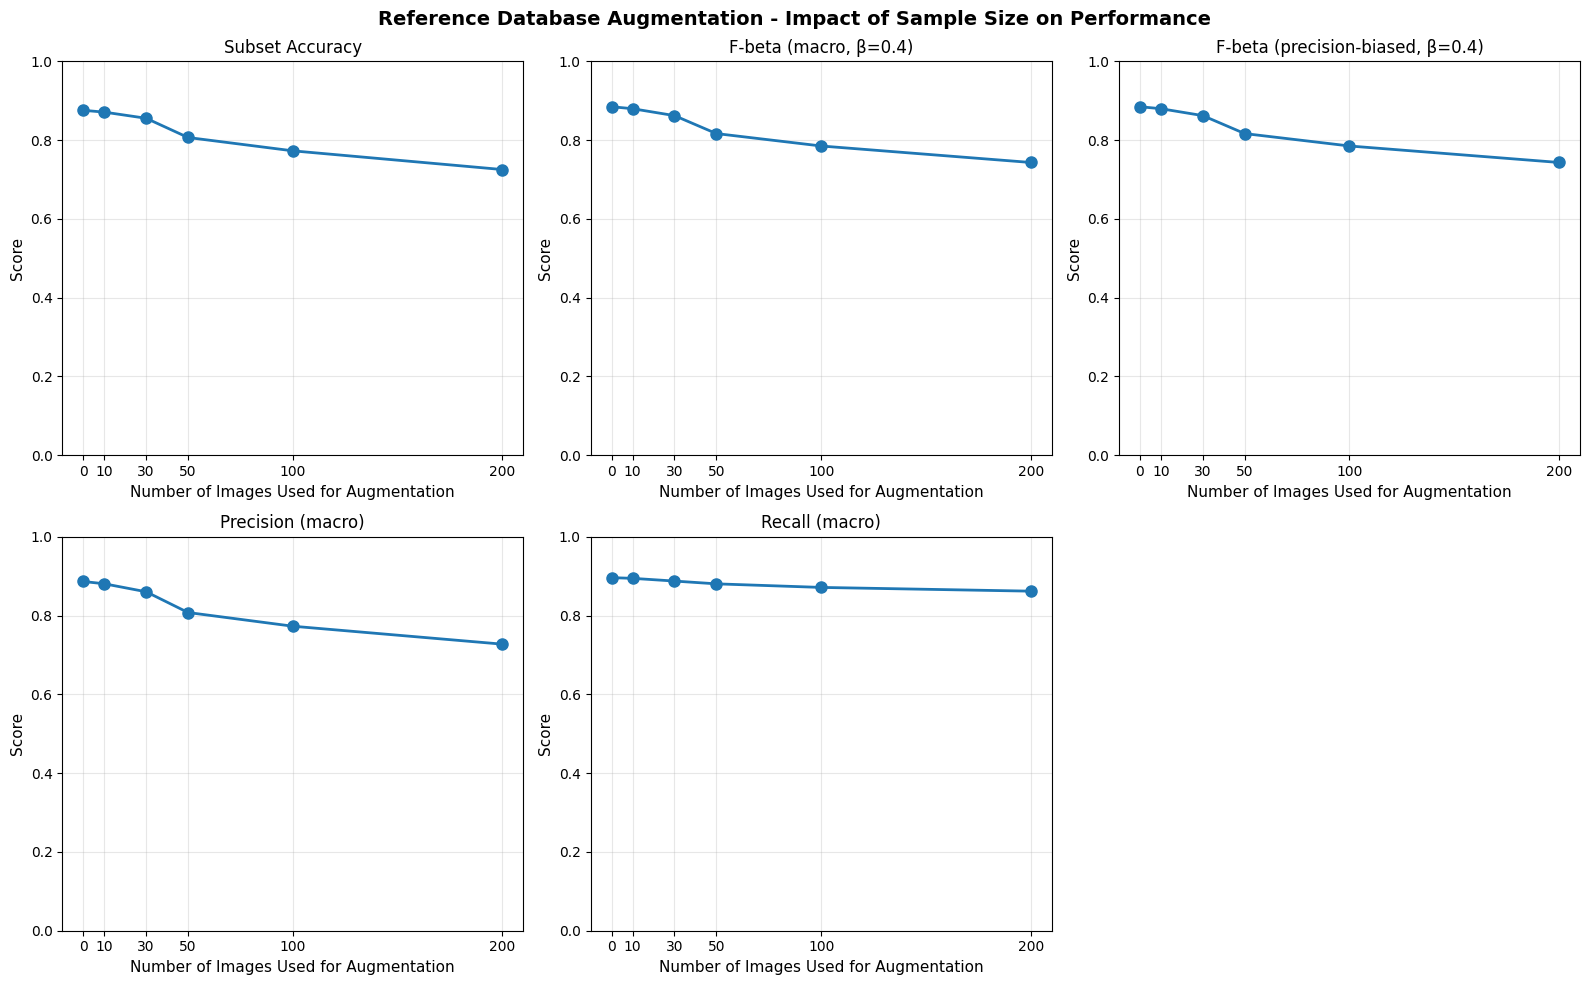

In [363]:
# Visualization: Performance across sample sizes
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Reference Database Augmentation - Impact of Sample Size on Performance", fontsize=14, fontweight='bold')

metrics_to_plot = ["subset_accuracy", "f1_macro", "f1_precision_biased", "precision_macro", "recall_macro"]
metric_labels = ["Subset Accuracy", f"F-beta (macro, β={F1_BETA})", f"F-beta (precision-biased, β={F1_BETA})", "Precision (macro)", "Recall (macro)"]

for ax, metric, label in zip(axes.flat, metrics_to_plot, metric_labels):
    ax.plot(results_df['sample_size'], results_df[metric], marker='o', linewidth=2, markersize=8)
    ax.set_xlabel("Number of Images Used for Augmentation", fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    ax.set_xticks(SAMPLE_SIZES)

# Hide the last unused subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
viz_path = EXPERIMENT_DIR / "sampling_iterations_results.png"
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Visualization saved: {viz_path}")
plt.show()

## Per-Class Metrics for All Iterations

Visualize how per-class metrics change across all sampling iterations.


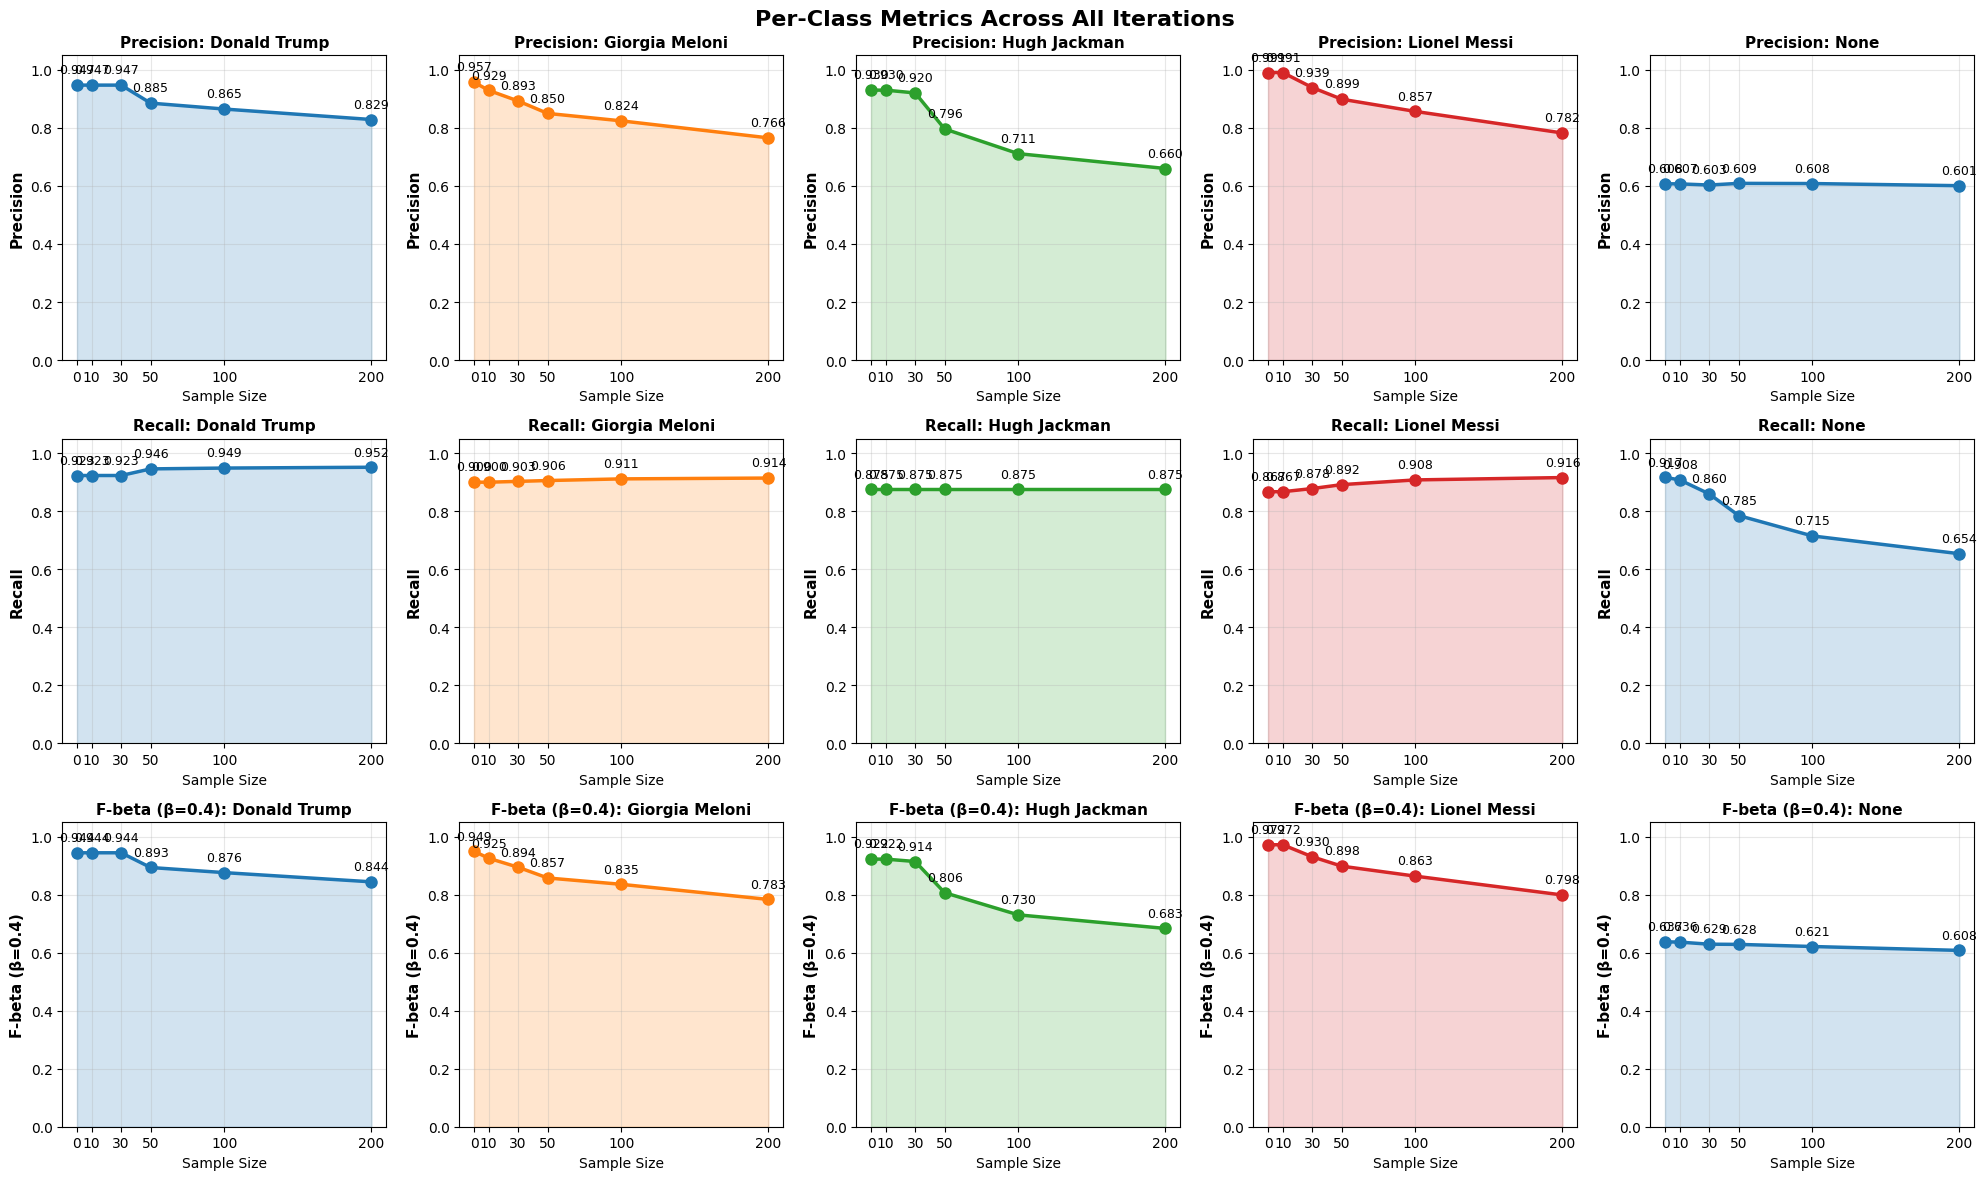


DETAILED METRICS BY ITERATION AND CLASS

Iteration 1: Sample Size = 0
----------------------------------------------------------------------------------------------------
                precision  recall      f1  support
Donald Trump       0.9474  0.9231  0.9439    351.0
Giorgia Meloni     0.9574  0.9000  0.9491    350.0
Hugh Jackman       0.9301  0.8750  0.9221    304.0
Lionel Messi       0.9907  0.8672  0.9716    369.0
None               0.6076  0.9167  0.6372    228.0

Macro Averages for this iteration:
  Precision: 0.886640
  Recall:    0.896400
  F-beta (β=0.4):  0.884780

Iteration 2: Sample Size = 10
----------------------------------------------------------------------------------------------------
                precision  recall      f1  support
Donald Trump       0.9474  0.9231  0.9439    351.0
Giorgia Meloni     0.9292  0.9000  0.9251    350.0
Hugh Jackman       0.9301  0.8750  0.9221    304.0
Lionel Messi       0.9907  0.8672  0.9716    369.0
None               0.6070  

In [364]:
if iteration_metrics:
    # Extract class names from first iteration
    classes = list(iteration_metrics[0].keys()) if iteration_metrics[0] else []
    sample_sizes = [result['sample_size'] for result in experiment_results]
    
    if classes:
        # Create subplots - one row per metric, one column per class
        fig, axes = plt.subplots(3, len(classes), figsize=(4*len(classes), 12))
        fig.suptitle("Per-Class Metrics Across All Iterations", fontsize=16, fontweight='bold')
        
        # Ensure axes is 2D even with single class
        if len(classes) == 1:
            axes = axes.reshape(-1, 1)
        
        metrics_list = ['precision', 'recall', 'f1']
        metric_titles = ['Precision', 'Recall', f'F-beta (β={F1_BETA})']
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        
        # For each metric
        for metric_idx, (metric_name, metric_title) in enumerate(zip(metrics_list, metric_titles)):
            # For each class
            for class_idx, class_name in enumerate(classes):
                ax = axes[metric_idx, class_idx]
                
                # Extract values for this class across all iterations
                values = []
                for iter_metrics in iteration_metrics:
                    if class_name in iter_metrics:
                        values.append(iter_metrics[class_name][metric_name])
                    else:
                        values.append(0)
                
                # Plot
                ax.plot(sample_sizes, values, marker='o', linewidth=2.5, markersize=8, 
                       color=colors[class_idx % len(colors)], label=class_name)
                ax.fill_between(sample_sizes, values, alpha=0.2, color=colors[class_idx % len(colors)])
                
                # Labels and formatting
                ax.set_ylabel(metric_title, fontsize=11, fontweight='bold')
                ax.set_xlabel('Sample Size', fontsize=10)
                ax.set_title(f'{metric_title}: {class_name}', fontsize=11, fontweight='bold')
                ax.set_ylim([0, 1.05])
                ax.grid(True, alpha=0.3)
                ax.set_xticks(sample_sizes)
                
                # Add value labels on points
                for x, y in zip(sample_sizes, values):
                    ax.text(x, y + 0.03, f'{y:.3f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "=" * 100)
        print("DETAILED METRICS BY ITERATION AND CLASS")
        print("=" * 100)
        
        # Print detailed table for each iteration
        for iter_idx, (sample_size, metrics_dict) in enumerate(zip(sample_sizes, iteration_metrics)):
            print(f"\nIteration {iter_idx + 1}: Sample Size = {sample_size}")
            print("-" * 100)
            
            metrics_df = pd.DataFrame(metrics_dict).T
            metrics_df = metrics_df.round(4)
            print(metrics_df.to_string())
            
            # Summary stats
            print(f"\nMacro Averages for this iteration:")
            print(f"  Precision: {metrics_df['precision'].mean():.6f}")
            print(f"  Recall:    {metrics_df['recall'].mean():.6f}")
            print(f"  F-beta (β={F1_BETA}):  {metrics_df['f1'].mean():.6f}")
    else:
        print("⚠️  No class data available. Run experiments first.")
else:
    print("⚠️  No iteration metrics available. Re-run experiments to capture per-class metrics for each iteration.")


In [365]:
# # Save results to CSV
# csv_path = EXPERIMENT_DIR / "sampling_iterations_results.csv"
# results_df.to_csv(csv_path, index=False)
# print(f"✓ Results saved to CSV: {csv_path}")

# # Save detailed summary
# summary_path = EXPERIMENT_DIR / "summary.txt"
# with open(summary_path, 'w') as f:
#     f.write("=" * 80 + "\n")
#     f.write("REFERENCE DATABASE AUGMENTATION EXPERIMENTS - SUMMARY\n")
#     f.write("=" * 80 + "\n\n")
#     f.write(f"Timestamp: {datetime.datetime.now().isoformat()}\n")
#     f.write(f"Training set: {TRAINSET_PATH.name}\n")
#     f.write(f"Total training images: {len(train_items)}\n\n")
    
#     f.write("EXPERIMENT DESIGN:\n")
#     f.write("-" * 80 + "\n")
#     f.write("Reference Database: All 4 identities (Hugh Jackman, Donald Trump, Giorgia Meloni, Lionel Messi)\n")
#     f.write("Selection Method: High-confidence face addition (similarity threshold = 0.5)\n")
#     f.write("Augmentation Strategy: Randomly select N images from training set to find high-confidence faces\n")
#     f.write("Evaluation: Measure performance on full training set after augmentation\n\n")
    
#     f.write("SAMPLING ITERATIONS:\n")
#     f.write("-" * 80 + "\n")
#     for size in SAMPLE_SIZES:
#         if size == 0:
#             f.write(f"  Size {size}: Baseline (no augmentation)\n")
#         else:
#             f.write(f"  Size {size}: Randomly select {size} images for augmentation\n")
    
#     f.write("\n" + "=" * 80 + "\n")
#     f.write("RESULTS\n")
#     f.write("=" * 80 + "\n\n")
#     f.write(results_df.to_string(index=False))
    
#     f.write("\n\n" + "=" * 80 + "\n")
#     f.write("BEST PERFORMING SAMPLE SIZES\n")
#     f.write("=" * 80 + "\n")
#     for metric in ["subset_accuracy", "f1_macro", "precision_macro", "recall_macro"]:
#         best_idx = results_df[metric].idxmax()
#         best_row = results_df.loc[best_idx]
#         f.write(f"\nBest {metric}:\n")
#         f.write(f"  Sample size: {int(best_row['sample_size'])} images\n")
#         f.write(f"  Score: {best_row[metric]:.4f}\n")

# print(f"✓ Summary saved: {summary_path}")